# Deep Kernel GP Regression — DKL-driven BEPS experiment on a *simulated* microscope

This notebook demonstrates **Deep Kernel Gaussian Process Regression (DKGPR)** driving a Band Excitation
Piezoresponse Spectroscopy (BEPS) experiment on a PTO thin film.

**What changed relative to `ENGAGE_DKGPR_PiezoResponse.ipynb`:** that notebook loaded a pre-recorded
`.npz` file and had the loop area of *every* pixel available up front, so the "active learning" loop only
revealed labels it already held. Here the data comes from
[`mexpsimu`](https://pypi.org/project/mexpsimu/), a microscopy experiment simulator that plays a recorded
dataset back through the same three operations a real acquisition control loop uses:

| operation | call | cost |
|---|---|---|
| image scan | `scope.scan_image(channel)` | cheap, done once |
| move tip | `scope.move_tip(x, y)` | cheap |
| local spectroscopy | `scope.spectroscopy()` | **expensive — this is what the acquisition function spends** |

The DKL inputs (image patches) come from a single up-front image scan. The DKL *targets* (hysteresis loop
areas) do not exist until the tip is driven to a location and a spectrum is measured. Every label in the
training set is therefore produced by an actual simulated measurement, and the acquisition function decides
where the tip goes next.

**Goal:** given a 20×20 image patch around a candidate pixel, predict the ferroelectric hysteresis
**loop area** at that pixel, and use UCB to choose where to measure next.

**Model:** a deep feature extractor maps each patch to a low-dimensional feature vector; a Gaussian Process
uses those features as inputs (deep kernel) and is trained by maximizing the marginal log-likelihood.

**Sections:**
1. Setup
2. Connect to the simulated microscope
3. The acquisition step (`scope.spectroscopy`) and the loop-area scalarizer
4. Candidate inputs from a single image scan
5. Iterative active learning loop (UCB), measuring on demand

**Author:** Yongtao Liu, summer project for Jiawei Gong

## 1. Setup

Required packages: `numpy`, `matplotlib`, `torch`, `engage-gp` and `mexpsimu`.
`opencv-python` is no longer needed — the original notebook used it only to resize the amplitude image onto
the spectroscopy grid, and the simulator already reports both grids.

In [1]:
from warnings import filterwarnings

import numpy as np
import matplotlib.pyplot as plt
import torch

from engagegp import fit_dkgp
from engagegp.utils import get_grid_coords, get_subimages   # image patch utilities

import mexpsimu

filterwarnings("ignore", category=UserWarning)

np.random.seed(42)
torch.manual_seed(42)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", DEVICE)

c:\Users\yla\Downloads\New folder\.venv\Lib\site-packages\torch\jit\_script.py:1491: FutureWarning: `torch.jit.script` is deprecated. Please switch to `torch.compile` or `torch.export`.
  warnings.warn(


device: cpu


## 2. Connect to the simulated microscope

`mexpsimu` bundles several presets, named after their physical scan size. We use `PTO_BEPS_1d3um`: a
65 × 65 grid over a 1.3 µm scan, with 192 voltage steps (3 bipolar ±12 V cycles) recorded at every grid
point. Change `PRESET` to try the others.

The `Microscope` object is the only interface to the sample from here on — no data file is read directly.

In [2]:
print("available presets:", mexpsimu.list_presets())

PRESET = "PTO_BEPS_1d3um"
scope = mexpsimu.Microscope(PRESET)

print(scope)
print("image channels :", scope.list_channels())
print("voltage source :", scope.voltage_source)

available presets: ['PTO_BEPS_1d3um', 'PTO_BEPS_1d7um', 'PTO_BEPS_3um', 'artificial_defect_cAFM']
Microscope(dataset='PTO_BEPS_1d3um', image_shape=(65, 65), measurement_shape=(65, 65), position=TipPosition(row=32, col=32, x_um=0.65, y_um=0.65))
image channels : ['image', 'image2']
voltage source : recorded


### Image scan

One full-frame scan gives us the structural context for every candidate location. `image` is the PFM
domain-contrast channel (used as the structure image); `image2` is a derived mean-response map.
`scope.excitation_waveform` is the DC bias applied at each spectroscopy step.

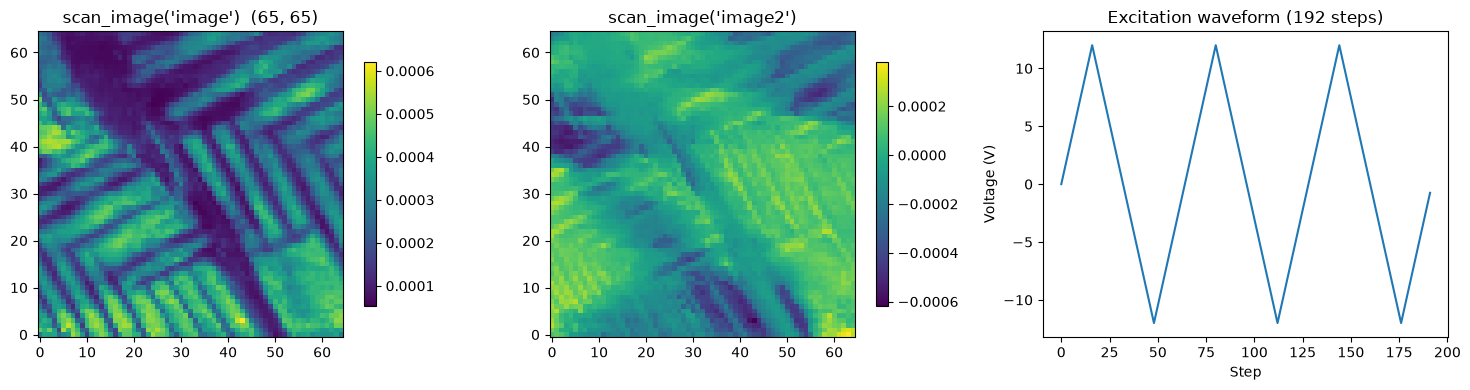

In [3]:
struc_img = scope.scan_image("image")     # structure image -> DKL inputs
resp_img  = scope.scan_image("image2")    # mean piezoresponse map (context only)
v_step    = scope.excitation_waveform     # DC bias (V) at each spectroscopy step

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 4))
im1 = ax1.imshow(struc_img, cmap='viridis', origin='lower')
ax1.set_title(f"scan_image('image')  {struc_img.shape}")
fig.colorbar(im1, ax=ax1, shrink=0.8)
im2 = ax2.imshow(resp_img, cmap='viridis', origin='lower')
ax2.set_title("scan_image('image2')")
fig.colorbar(im2, ax=ax2, shrink=0.8)
ax3.plot(v_step)
ax3.set_xlabel('Step'); ax3.set_ylabel('Voltage (V)')
ax3.set_title(f'Excitation waveform ({len(v_step)} steps)')
plt.tight_layout(); plt.show()

## 3. The acquisition step

The expensive operation of the experiment is `scope.spectroscopy(x, y, units="px")`, which moves the tip to
a pixel and returns `(voltage, response)` — the DC bias waveform paired with the local piezoresponse loop.
It is called directly wherever a measurement is needed, with no wrapper in between.

One detail to keep in mind at every call site: `move_tip` / `spectroscopy` take `x` = **column** and
`y` = **row**, the opposite order to the `(row, col)` array indexing used by the patch utilities. So a
candidate at `coords[i] = (row, col)` is measured with `scope.spectroscopy(col, row, units="px")`.

Pixel indices are shared between the image channels and the spectroscopy grid, which is what makes the
direct call valid — the assertion below makes that explicit (it holds for every bundled preset, and
replaces the `cv2.resize` step of the original notebook).

In [4]:
print(f"image grid       : {scope.dataset.image_shape}")
print(f"spectroscopy grid: {scope.dataset.measurement_shape}")

assert scope.dataset.image_shape == scope.dataset.measurement_shape, (
    "image and spectroscopy grids differ for this dataset; image pixel indices would need to be "
    "rescaled onto the measurement grid before calling spectroscopy()"
)

# One measurement, to see what the call returns
voltage, response = scope.spectroscopy(30, 30, units="px")   # x=col, y=row
print(f"tip now at {scope.position}")
print(f"voltage {voltage.shape}, response {response.shape}")

image grid       : (65, 65)
spectroscopy grid: (65, 65)
tip now at TipPosition(row=30, col=30, x_um=0.609375, y_um=0.609375)
voltage (192,), response (192,)


### The scalarizer: hysteresis loop area

A spectrum is turned into the scalar the DKL model predicts. The loop area reflects the energy dissipated
per polarization reversal cycle — larger area means stronger ferroelectric switching at that location.

The original notebook split the waveform by hard-coded index arithmetic for a 3-cycle sweep. Since the
simulator hands back the actual excitation waveform alongside every spectrum, we split the branches by the
sign of `dV` instead, which works for any number of cycles (`PTO_BEPS_1d7um`, for instance, uses 8).
`loop_area_cycles` below is the original index-based descriptor, kept for comparison — on this preset the
two agree to r = 0.99.

In [5]:
def loop_area(response, voltage):
    """Hysteresis loop area: |sum(descending branches) - sum(ascending branches)|."""
    dv = np.gradient(voltage)
    return np.abs(np.sum(response[dv < 0]) - np.sum(response[dv > 0]))


def loop_area_cycles(raw_spec, cycle=3):
    """The original index-based descriptor, for a sweep with `cycle` bipolar cycles."""
    cycle_len = int(len(raw_spec) / cycle)
    half_len  = int(cycle_len / 2)
    q_len     = int(cycle_len / 4)
    top_parts = [
        raw_spec[q_len              : q_len +   half_len],
        raw_spec[q_len + 2*half_len : q_len + 3*half_len],
        raw_spec[q_len + 4*half_len : 2*q_len + 4*half_len],
    ]
    bot_parts = [
        raw_spec[:q_len],
        raw_spec[q_len +   half_len : q_len + 2*half_len],
        raw_spec[q_len + 3*half_len : q_len + 4*half_len],
    ]
    return np.abs(np.sum(np.concatenate(top_parts)) - np.sum(np.concatenate(bot_parts)))


def norm_(x):
    """Scale to [0, 1]; a constant input maps to zeros instead of NaN."""
    x = np.asarray(x, dtype=float)
    rng = np.ptp(x)
    return (x - x.min()) / (rng if rng > 0 else 1.0)


def plot_loss(losses, title=''):
    """Training loss curve."""
    plt.figure(figsize=(5, 3))
    plt.plot(losses)
    plt.xlabel('Epoch'); plt.ylabel('Negative MLL')
    if title: plt.title(title)
    plt.tight_layout(); plt.show()

## 4. Candidate inputs from the image scan

The DKL inputs are 20 × 20 patches of the structure image centred on each candidate pixel — all derived
from the single image scan above, so building them costs no spectroscopy. The patch centres are the
candidate locations the acquisition function chooses between.

In [7]:
img = norm_(struc_img)

coordinates = get_grid_coords(img, step=1)      # all (row, col) positions
window_size = 20

features_all, coords, _ = get_subimages(img, coordinates, window_size)
features_all = features_all[:, :, :, 0]         # drop channel axis -> (N, 20, 20)
coords       = np.array(coords, dtype=int)      # (row, col) of each patch centre

n, d1, d2 = features_all.shape
X = features_all.reshape(n, d1 * d2)            # (N, 400) inputs for the feature extractor

print(f"Patches : {features_all.shape}   (N, height, width)")
print(f"Coords  : {coords.shape}         (N, 2) as (row, col)")
print(f"Input X : {X.shape}              (N_candidates x input_dim)")
print("No targets exist yet - they are measured on demand.")

Patches : (2116, 20, 20)   (N, height, width)
Coords  : (2116, 2)         (N, 2) as (row, col)
Input X : (2116, 400)              (N_candidates x input_dim)
No targets exist yet - they are measured on demand.


## 5. Iterative active learning loop (UCB)

The loop is the same as before, with one step replaced by a real measurement:

1. Fit a DKL model on the currently measured points
2. Compute **UCB** = `mean + beta * std` over all candidate locations
3. Select the candidate with the largest UCB (excluding locations already measured)
4. **Drive the tip there and measure the spectrum**, scalarize it to a loop area, add it to the training set
5. Repeat

Larger `beta` explores more.

### A note on prediction

`engagegp.predict_dkgpr` (and the `upper_confidence_bound` / `expected_improvement` helpers, which share its
code path) calls the model's `forward`, i.e. `gp_model(features)`. `DeepKernelGP` builds its `SingleTaskGP`
with `Normalize` and `Standardize` transforms, but `update_gp_data()` re-sets the training data with *raw*
features each epoch. On that path the stored training inputs live in a different space from the
transformed test features, and the outcome transform is never applied — so the predictions do not track the
training targets. BoTorch's `posterior()` API applies the transforms consistently, so `dkgp_predict` below
uses it and then undoes the (unused) `Standardize` to return values on the scale of `y`.

Swap `dkgp_predict` back for `predict_dkgpr` once that is fixed upstream; everything else here is the
documented ENGAGEGP API.

In [8]:
def dkgp_predict(dkl, X_query, batch_size=2048):
    """Posterior mean and standard deviation of an ENGAGEGP model, on the scale of the training targets."""
    dkl.eval()
    X_query = np.asarray(X_query, dtype=np.float64)
    means, stds = [], []
    with torch.no_grad():
        for start in range(0, len(X_query), batch_size):
            batch = torch.from_numpy(X_query[start:start + batch_size]).double().to(DEVICE)
            posterior = dkl.gp_model.posterior(dkl.feature_extractor(batch))
            means.append(posterior.mean.squeeze(-1).cpu().numpy())
            stds.append(posterior.variance.squeeze(-1).sqrt().cpu().numpy())
    mean = np.concatenate(means)
    std  = np.concatenate(stds)

    # undo the Standardize outcome transform, which the training loop bypasses
    outcome = dkl.gp_model.outcome_transform
    scale, offset = outcome.stdvs.item(), outcome.means.item()
    return (mean - offset) / scale, std / scale

### Initial design

Five random locations are measured to seed the model. This is the only part of the training set that is not
chosen by the acquisition function.

In [9]:
np.random.seed(5)
start_size = 5

measured_idx = list(np.random.choice(np.arange(1, n), size=start_size, replace=False).astype(int))

# Acquire the seed measurements: drive the tip to each location and read the loop
y_raw = [
    loop_area(scope.spectroscopy(coords[i, 1], coords[i, 0], units="px")[1], v_step)
    for i in measured_idx
]

print(f'{len(measured_idx)} seed measurements acquired out of {n} candidate locations')
for i, y in zip(measured_idx, y_raw):
    print(f'  (row={coords[i,0]:3d}, col={coords[i,1]:3d})  loop area = {y:.3e}')

5 seed measurements acquired out of 2116 candidate locations
  (row= 14, col= 28)  loop area = 7.527e-03
  (row= 38, col= 19)  loop area = 2.057e-02
  (row= 23, col= 19)  loop area = 3.421e-02
  (row= 38, col= 21)  loop area = 6.278e-03
  (row= 38, col= 39)  loop area = 1.133e-02


Step 1/20 | n_measured=5


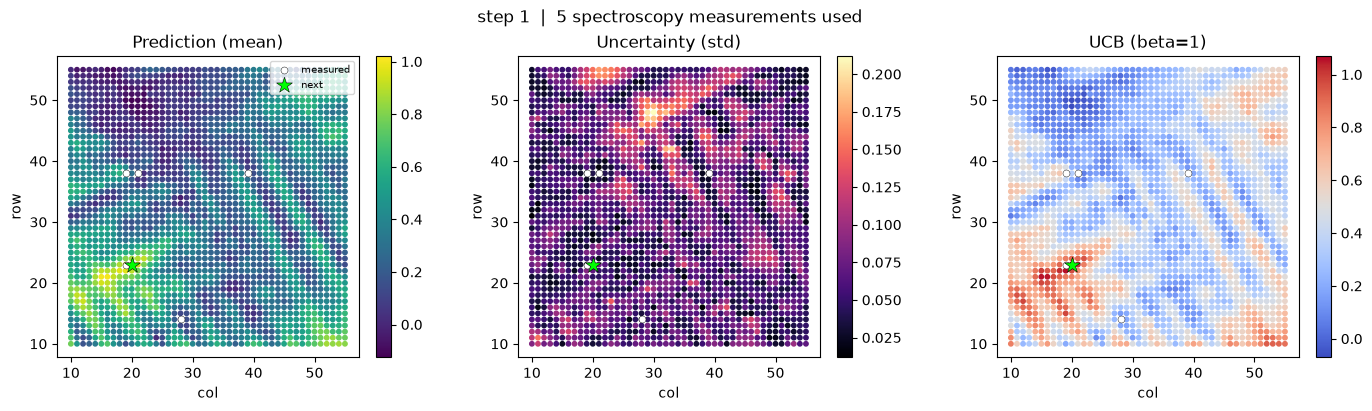

Step 2/20 | n_measured=6
Step 3/20 | n_measured=7
Step 4/20 | n_measured=8
Step 5/20 | n_measured=9
Step 6/20 | n_measured=10


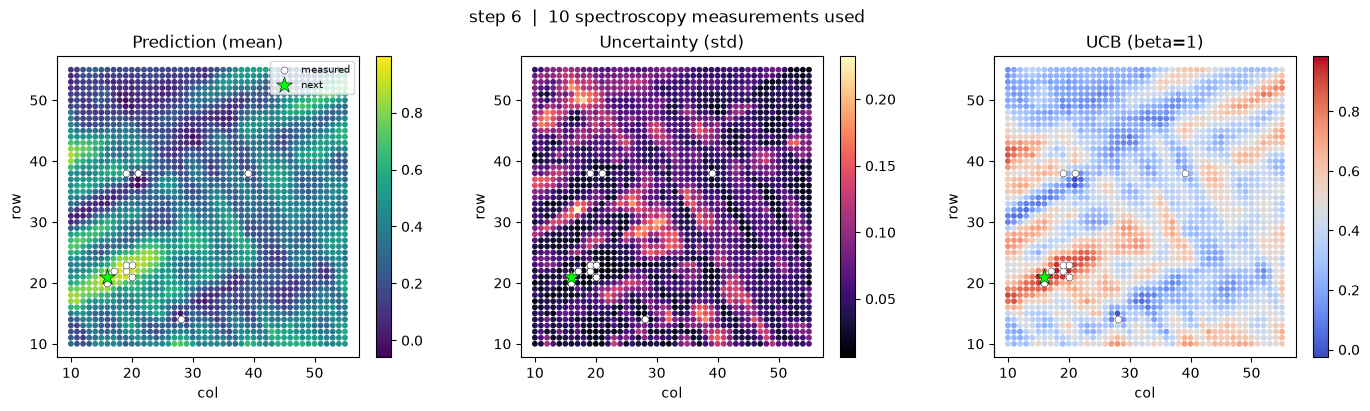

Step 7/20 | n_measured=11
Step 8/20 | n_measured=12
Step 9/20 | n_measured=13
Step 10/20 | n_measured=14
Step 11/20 | n_measured=15


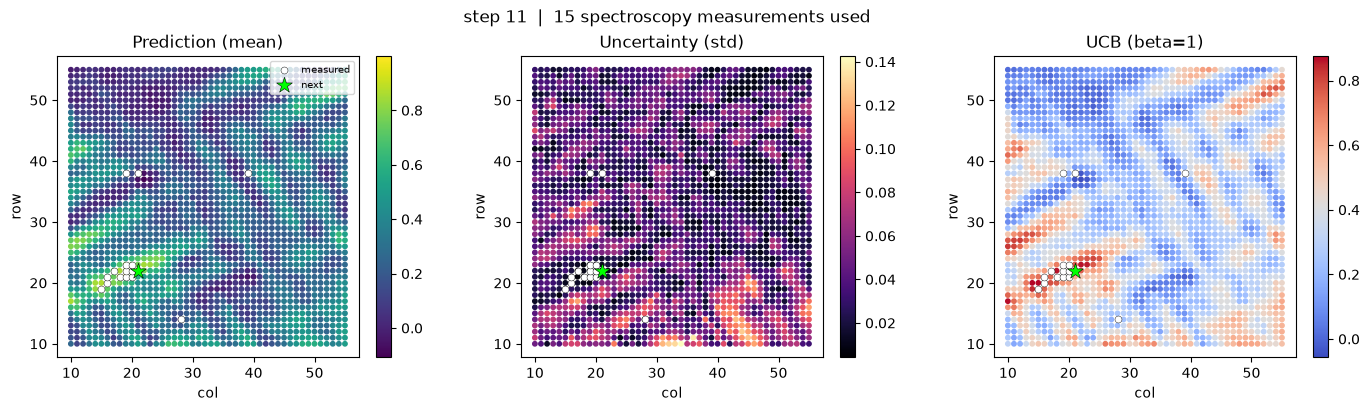

Step 12/20 | n_measured=16
Step 13/20 | n_measured=17
Step 14/20 | n_measured=18
Step 15/20 | n_measured=19
Step 16/20 | n_measured=20


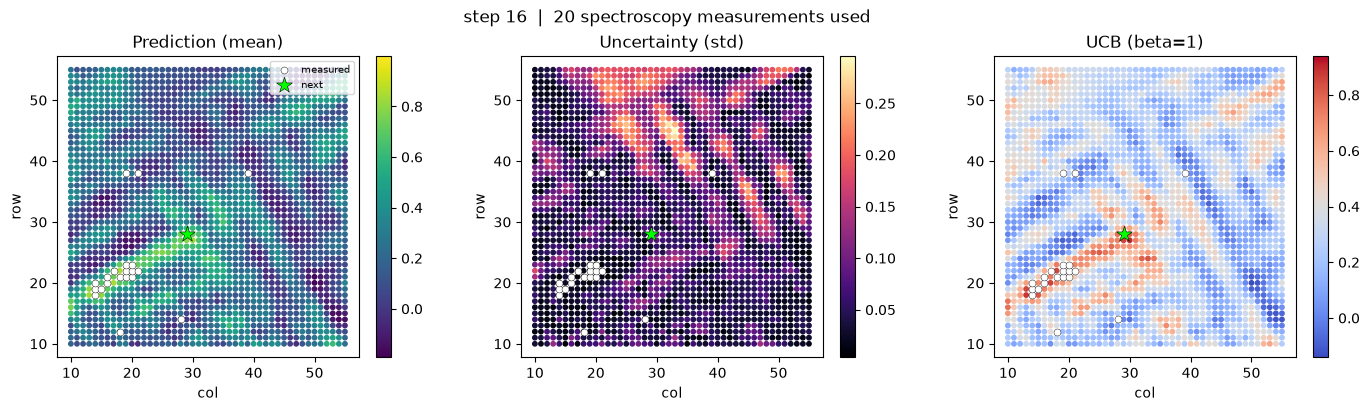

Step 17/20 | n_measured=21
Step 18/20 | n_measured=22
Step 19/20 | n_measured=23
Step 20/20 | n_measured=24


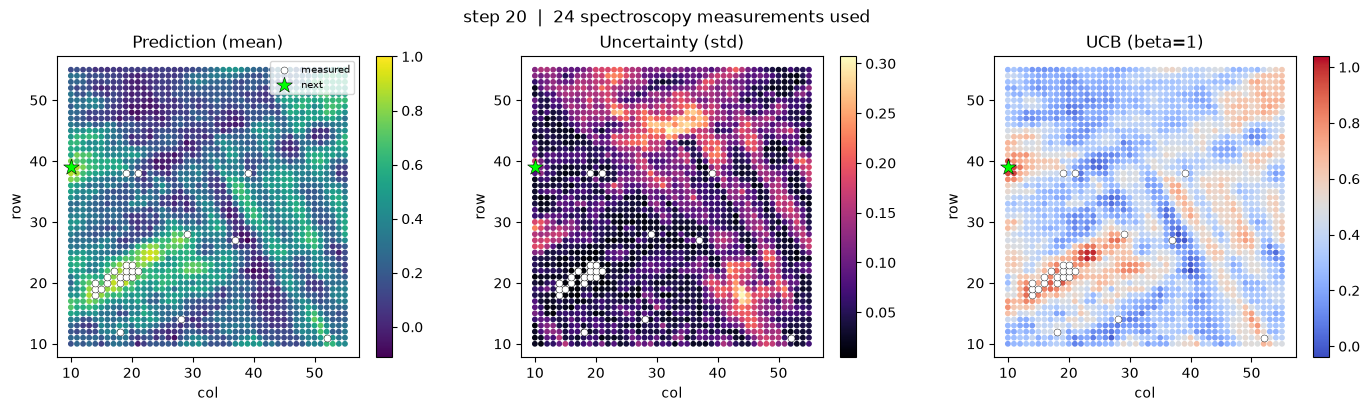

Training Deep Kernel GP Regression Model
Feature Extractor: fc

Auto-selected: ExactMarginalLogLikelihood

Training Deep Kernel GP
  Device: cpu
  Extractor type: fc
  Input dim: 400 → Feature dim: 4
  Data points: 25
  Hidden layers: [256, 128, 64]
  MLL: ExactMarginalLogLikelihood
  Epoch  100/2000, Loss: 0.4739
  Epoch  200/2000, Loss: 0.0202
  Epoch  300/2000, Loss: -0.4286
  Epoch  400/2000, Loss: -0.7322
  Epoch  500/2000, Loss: -0.9574
  Epoch  600/2000, Loss: -1.1756
  Epoch  700/2000, Loss: -1.2858
  Epoch  800/2000, Loss: -1.4884
  Epoch  900/2000, Loss: -1.6024
  Epoch 1000/2000, Loss: -1.6806
  Epoch 1100/2000, Loss: -1.7579
  Epoch 1200/2000, Loss: -1.8397
  Epoch 1300/2000, Loss: -1.9344
  Epoch 1400/2000, Loss: -2.0023
  Epoch 1500/2000, Loss: -2.0578
  Epoch 1600/2000, Loss: -2.1062
  Epoch 1700/2000, Loss: -2.1543
  Epoch 1800/2000, Loss: -2.2013
  Epoch 1900/2000, Loss: -2.2464
  Epoch 2000/2000, Loss: -2.2896
Training complete! Final loss: -2.2896


In [10]:
# Active learning settings
beta    = 1        # exploration strength
n_steps = 20       # acquisition iterations; each one costs a spectroscopy measurement

# Model settings
extractor_type = 'fc'
feature_dim    = 4
num_epochs     = 2000      # per-iteration training epochs (reduce for speed)

plot_every = 5     # draw the diagnostic panel every N steps (set to 1 to plot every step)

best_so_far = []

for t in range(n_steps):
    order       = np.argsort(measured_idx)
    idx_sorted  = np.array(measured_idx, dtype=int)[order]
    X_train     = X[idx_sorted]
    y_train     = norm_(np.array(y_raw)[order])   # normalized over what has actually been measured
    coord_train = coords[idx_sorted]

    print(f"Step {t+1}/{n_steps} | n_measured={len(measured_idx)}")

    # 1. Fit the DKL model on the measured points
    mll, gp_model, dkl_model, losses = fit_dkgp(
        X_train, y_train,
        feature_dim=feature_dim,
        extractor_type=extractor_type,
        num_epochs=num_epochs,
        device=DEVICE,
        verbose=False,
    )

    # 2. Predict over all candidates and form the UCB acquisition
    mean, std = dkgp_predict(dkl_model, X)
    ucb = mean + beta * std

    # 3. Select the next location, excluding everything already measured
    ucb_masked = ucb.copy()
    ucb_masked[measured_idx] = -np.inf
    next_idx = int(np.argmax(ucb_masked))
    next_row, next_col = coords[next_idx]

    if t % plot_every == 0 or t == n_steps - 1:
        fig, axes = plt.subplots(1, 3, figsize=(14, 4), constrained_layout=True)
        panels = [(mean, 'viridis', 'Prediction (mean)'),
                  (std, 'magma', 'Uncertainty (std)'),
                  (ucb_masked, 'coolwarm', f'UCB (beta={beta})')]
        for ax, (vals, cmap, title) in zip(axes, panels):
            sc = ax.scatter(coords[:, 1], coords[:, 0], c=vals, s=10, cmap=cmap)
            ax.scatter(coord_train[:, 1], coord_train[:, 0], c='white', s=25,
                       edgecolor='k', linewidth=0.3, label='measured')
            ax.scatter(next_col, next_row, marker='*', c='lime', s=140,
                       edgecolor='k', linewidth=0.4, label='next')
            ax.set_title(title); ax.set_aspect('equal')
            ax.set_xlabel('col'); ax.set_ylabel('row')
            fig.colorbar(sc, ax=ax)
        axes[0].legend(loc='upper right', fontsize=7)
        fig.suptitle(f'step {t+1}  |  {len(measured_idx)} spectroscopy measurements used')
        plt.show()

    # 4. Drive the tip to the selected location and measure it
    _, response = scope.spectroscopy(next_col, next_row, units="px")   # x=col, y=row
    y_next = loop_area(response, v_step)
    measured_idx.append(next_idx)
    y_raw.append(y_next)

    best_so_far.append(float(np.max(y_raw)))

# Final refit on everything that was measured
order       = np.argsort(measured_idx)
idx_sorted  = np.array(measured_idx, dtype=int)[order]
X_train     = X[idx_sorted]
y_train     = norm_(np.array(y_raw)[order])
coord_train = coords[idx_sorted]

mll, gp_model, dkl_al, losses_al = fit_dkgp(
    X_train, y_train,
    feature_dim=feature_dim,
    extractor_type=extractor_type,
    num_epochs=2000,
    device=DEVICE,
    verbose=True,
)

mean_al, std_al = dkgp_predict(dkl_al, X)

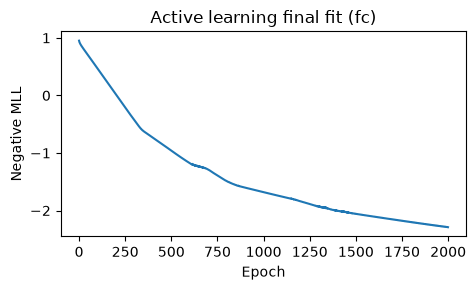

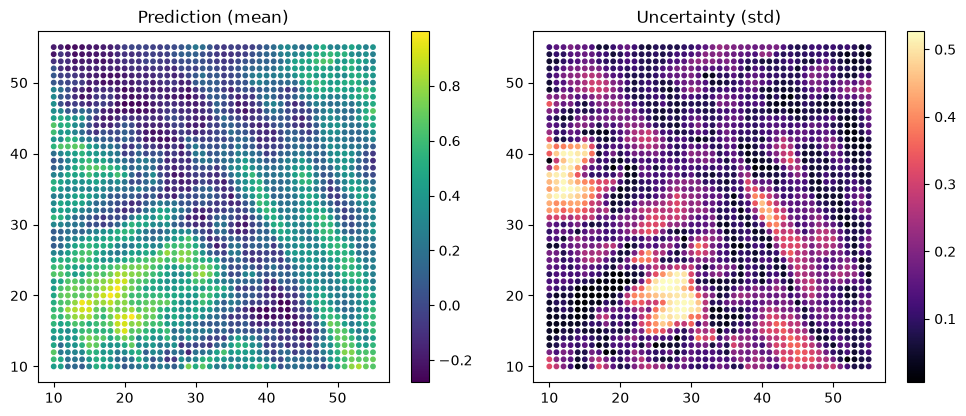

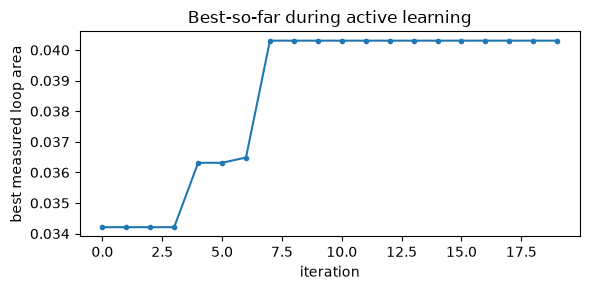

In [11]:
# Visualize results after active learning
plot_loss(losses_al, f'Active learning final fit ({extractor_type})')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
a = ax1.scatter(coords[:, 1], coords[:, 0], c=mean_al, cmap='viridis', s=10)
plt.colorbar(a, ax=ax1); ax1.set_title('Prediction (mean)'); ax1.set_aspect('equal')
b = ax2.scatter(coords[:, 1], coords[:, 0], c=std_al, cmap='magma', s=10)
plt.colorbar(b, ax=ax2); ax2.set_title('Uncertainty (std)'); ax2.set_aspect('equal')
plt.tight_layout(); plt.show()

plt.figure(figsize=(6, 3))
plt.plot(best_so_far, marker='o', markersize=3)
plt.xlabel('iteration'); plt.ylabel('best measured loop area')
plt.title('Best-so-far during active learning')
plt.tight_layout(); plt.show()

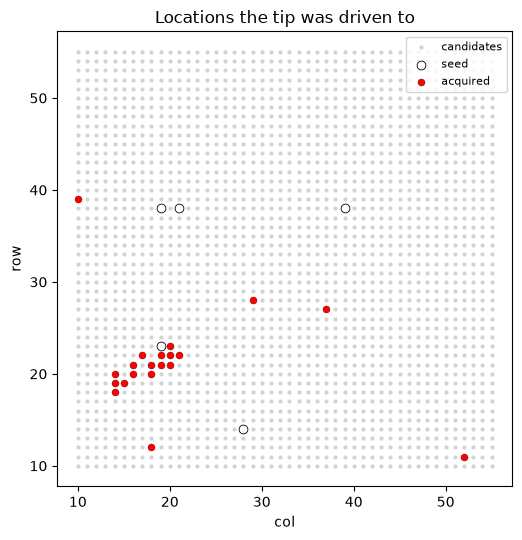

In [12]:
# Where the tip actually went: seed design vs. acquired locations
init_idx = np.array(measured_idx[:start_size], dtype=int)
acq_idx  = np.array(measured_idx[start_size:], dtype=int)

plt.figure(figsize=(5.5, 5.5))
plt.scatter(coords[:, 1], coords[:, 0], s=4, c='lightgray', label='candidates')
plt.scatter(coords[init_idx, 1], coords[init_idx, 0], s=40, c='white',
            edgecolor='k', linewidth=0.6, label='seed')
plt.scatter(coords[acq_idx, 1], coords[acq_idx, 0], s=26, c='red',
            edgecolor='k', linewidth=0.2, label='acquired')
plt.gca().set_aspect('equal')
plt.xlabel('col'); plt.ylabel('row')
plt.title('Locations the tip was driven to')
plt.legend(fontsize=8)
plt.tight_layout(); plt.show()